# SimMIM Mask Ratio Experiments

This notebook is used for controlled experiments on the official SimMIM implementation.

Goal:
- Study how different mask ratios affect training behavior.
- Keep other settings fixed.
- Compare losses and training trends.
- Produce report-ready results for the CS543 group project.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
%cd /content
!git clone

/content
Cloning into 'CS543_Reproducing_and_Analyzing_SimMIM'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 12 (delta 1), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 48.41 KiB | 812.00 KiB/s, done.
Resolving deltas: 100% (1/1), done.


In [15]:
%cd /content/CS543_Reproducing_and_Analyzing_SimMIM
!find . -maxdepth 2

/content/CS543_Reproducing_and_Analyzing_SimMIM
.
./notebooks
./notebooks/simmim_smoke_test.ipynb
./external_code_patches
./external_code_patches/main_simmim.py
./README.md
./Project Proposal.docx
./.git
./.git/branches
./.git/index
./.git/HEAD
./.git/refs
./.git/info
./.git/objects
./.git/packed-refs
./.git/config
./.git/hooks
./.git/description
./.git/logs


In [16]:
%cd /content/CS543_Reproducing_and_Analyzing_SimMIM
!pwd

/content/CS543_Reproducing_and_Analyzing_SimMIM
/content/CS543_Reproducing_and_Analyzing_SimMIM


In [17]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
Tesla T4


In [18]:
%cd /content
!rm -rf SimMIM
!git clone https://github.com/microsoft/SimMIM.git
%cd /content/SimMIM
!find . -maxdepth 2 | head -80

/content
Cloning into 'SimMIM'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 65 (delta 17), reused 9 (delta 9), pack-reused 32 (from 1)
Receiving objects: 100% (65/65), 289.62 KiB | 1.54 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/SimMIM
.
./requirements.txt
./data
./data/data_simmim.py
./data/data_finetune.py
./data/__init__.py
./SECURITY.md
./README.md
./figures
./figures/teaser.jpg
./lr_scheduler.py
./main_simmim.py
./config.py
./.gitignore
./models
./models/swin_transformer.py
./models/build.py
./models/__init__.py
./models/vision_transformer.py
./models/simmim.py
./optimizer.py
./configs
./configs/swin_base__800ep
./configs/swin_large__800ep
./configs/vit_base__800ep
./configs/swin_base__100ep
./CODE_OF_CONDUCT.md
./utils.py
./SUPPORT.md
./LICENSE
./logger.py
./main_finetune.py
./.git
./.git/branches
./.git/index
./.git/HEAD
./.git/refs
./.git/info
./.git/object

In [19]:
!pip uninstall -y timm
!pip install timm==0.4.12

Found existing installation: timm 0.4.12
Uninstalling timm-0.4.12:
  Successfully uninstalled timm-0.4.12
  Using cached timm-0.4.12-py3-none-any.whl.metadata (30 kB)
Using cached timm-0.4.12-py3-none-any.whl (376 kB)


In [20]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content
!rm -rf SimMIM
!git clone https://github.com/microsoft/SimMIM.git
%cd /content/SimMIM

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
Cloning into 'SimMIM'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 65 (delta 17), reused 9 (delta 9), pack-reused 32 (from 1)
Receiving objects: 100% (65/65), 289.62 KiB | 2.28 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/SimMIM


In [21]:
from pathlib import Path

path = Path("/content/SimMIM/main_simmim.py")
text = path.read_text()

old = '    parser.add_argument("--local_rank", type=int, required=True, help=\'local rank for DistributedDataParallel\')'
new = '''    parser.add_argument("--local_rank", "--local-rank", type=int, default=int(os.environ.get("LOCAL_RANK", 0)),
                        help='local rank for DistributedDataParallel')'''

if old in text:
    text = text.replace(old, new)
    path.write_text(text)
    print("Patched main_simmim.py successfully.")
else:
    print("Target line not found. Please inspect manually.")

Patched main_simmim.py successfully.


In [22]:
!grep -n "local_rank" /content/SimMIM/main_simmim.py

59:    parser.add_argument("--local_rank", "--local-rank", type=int, default=int(os.environ.get("LOCAL_RANK", 0)),


In [23]:
%cd /content
!rm -rf tiny_imagenet_like
!mkdir -p tiny_imagenet_like/train/dummy

!wget -O /content/tiny_imagenet_like/train/dummy/img1.jpg https://picsum.photos/256
!wget -O /content/tiny_imagenet_like/train/dummy/img2.jpg https://picsum.photos/257
!wget -O /content/tiny_imagenet_like/train/dummy/img3.jpg https://picsum.photos/258

!find /content/tiny_imagenet_like -maxdepth 3

/content
--2026-04-22 03:33:06--  https://picsum.photos/256
Resolving picsum.photos (picsum.photos)... 104.26.4.30, 104.26.5.30, 172.67.74.163, ...
Connecting to picsum.photos (picsum.photos)|104.26.4.30|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://fastly.picsum.photos/id/667/256/256.jpg?hmac=rGrRU1jT1VjVEBqENE1NVjwlJhVaDbYTmek8MkhI07k [following]
--2026-04-22 03:33:07--  https://fastly.picsum.photos/id/667/256/256.jpg?hmac=rGrRU1jT1VjVEBqENE1NVjwlJhVaDbYTmek8MkhI07k
Resolving fastly.picsum.photos (fastly.picsum.photos)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to fastly.picsum.photos (fastly.picsum.photos)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9315 (9.1K) [image/jpeg]
Saving to: ‘/content/tiny_imagenet_like/train/dummy/img1.jpg’

/content/tiny_image 100%[===================>]   9.10K  --.-KB/s    in 0s      

2026-04-22 03:33:07 (82.8 MB/s) - ‘/content/tiny_imagenet_like/tra

In [25]:
%cd /content/SimMIM
!pip install -r requirements.txt

/content/SimMIM


In [26]:
%cd /content/SimMIM

!python -m torch.distributed.launch --nproc_per_node 1 main_simmim.py \
  --cfg configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml \
  --data-path /content/tiny_imagenet_like/train \
  --batch-size 2 \
  --amp-opt-level O0 \
  --output /content/simmim_maskratio_output \
  --tag baseline \
  --opts TRAIN.EPOCHS 1 TRAIN.WARMUP_EPOCHS 0 PRINT_FREQ 1 SAVE_FREQ 1 DATA.NUM_WORKERS 2

/content/SimMIM
/usr/local/lib/python3.12/dist-packages/torch/distributed/launch.py:207: FutureWarning: The module torch.distributed.launch is deprecated
and will be removed in future. Use torchrun.
Note that --use-env is set by default in torchrun.
If your script expects `--local-rank` argument to be set, please
change it to read from `os.environ['LOCAL_RANK']` instead. See 
https://pytorch.org/docs/stable/distributed.html#launch-utility for 
further instructions

  main()
=> merge config from configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml
RANK and WORLD_SIZE in environ: 0/1
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
[rank0]:[W422 03:34:39.086666523 ProcessGroupNCCL.cpp:5138] Guessing device ID based on global rank. This can cause a hang if rank to GPU 

In [27]:
#0.25
!python -m torch.distributed.launch --nproc_per_node 1 main_simmim.py \
  --cfg configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml \
  --data-path /content/tiny_imagenet_like/train \
  --batch-size 2 \
  --amp-opt-level O0 \
  --output /content/simmim_maskratio_output \
  --tag mask025 \
  --opts TRAIN.EPOCHS 1 TRAIN.WARMUP_EPOCHS 0 PRINT_FREQ 1 SAVE_FREQ 1 DATA.NUM_WORKERS 2 DATA.MASK_RATIO 0.25

/usr/local/lib/python3.12/dist-packages/torch/distributed/launch.py:207: FutureWarning: The module torch.distributed.launch is deprecated
and will be removed in future. Use torchrun.
Note that --use-env is set by default in torchrun.
If your script expects `--local-rank` argument to be set, please
change it to read from `os.environ['LOCAL_RANK']` instead. See 
https://pytorch.org/docs/stable/distributed.html#launch-utility for 
further instructions

  main()
=> merge config from configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml
RANK and WORLD_SIZE in environ: 0/1
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
[rank0]:[W422 03:35:47.129719358 ProcessGroupNCCL.cpp:5138] Guessing device ID based on global rank. This can cause a hang if rank to GPU mapping is heter

In [28]:
#0.5
!python -m torch.distributed.launch --nproc_per_node 1 main_simmim.py \
  --cfg configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml \
  --data-path /content/tiny_imagenet_like/train \
  --batch-size 2 \
  --amp-opt-level O0 \
  --output /content/simmim_maskratio_output \
  --tag mask050 \
  --opts TRAIN.EPOCHS 1 TRAIN.WARMUP_EPOCHS 0 PRINT_FREQ 1 SAVE_FREQ 1 DATA.NUM_WORKERS 2 DATA.MASK_RATIO 0.50

/usr/local/lib/python3.12/dist-packages/torch/distributed/launch.py:207: FutureWarning: The module torch.distributed.launch is deprecated
and will be removed in future. Use torchrun.
Note that --use-env is set by default in torchrun.
If your script expects `--local-rank` argument to be set, please
change it to read from `os.environ['LOCAL_RANK']` instead. See 
https://pytorch.org/docs/stable/distributed.html#launch-utility for 
further instructions

  main()
=> merge config from configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml
RANK and WORLD_SIZE in environ: 0/1
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
[rank0]:[W422 03:36:59.872377515 ProcessGroupNCCL.cpp:5138] Guessing device ID based on global rank. This can cause a hang if rank to GPU mapping is heter

In [29]:
#0.75
!python -m torch.distributed.launch --nproc_per_node 1 main_simmim.py \
  --cfg configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml \
  --data-path /content/tiny_imagenet_like/train \
  --batch-size 2 \
  --amp-opt-level O0 \
  --output /content/simmim_maskratio_output \
  --tag mask075 \
  --opts TRAIN.EPOCHS 1 TRAIN.WARMUP_EPOCHS 0 PRINT_FREQ 1 SAVE_FREQ 1 DATA.NUM_WORKERS 2 DATA.MASK_RATIO 0.75

/usr/local/lib/python3.12/dist-packages/torch/distributed/launch.py:207: FutureWarning: The module torch.distributed.launch is deprecated
and will be removed in future. Use torchrun.
Note that --use-env is set by default in torchrun.
If your script expects `--local-rank` argument to be set, please
change it to read from `os.environ['LOCAL_RANK']` instead. See 
https://pytorch.org/docs/stable/distributed.html#launch-utility for 
further instructions

  main()
=> merge config from configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml
RANK and WORLD_SIZE in environ: 0/1
/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
[rank0]:[W422 03:37:38.337744920 ProcessGroupNCCL.cpp:5138] Guessing device ID based on global rank. This can cause a hang if rank to GPU mapping is heter

In [30]:
import subprocess
import re
import pandas as pd
import numpy as np
from IPython.display import display

BASE_CMD = """
python -m torch.distributed.launch --nproc_per_node 1 main_simmim.py \
--cfg configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml \
--data-path /content/tiny_imagenet_like/train \
--batch-size 2 \
--amp-opt-level O0 \
--output /content/simmim_repeat_output \
--tag {tag} \
--opts TRAIN.EPOCHS 1 TRAIN.WARMUP_EPOCHS 0 PRINT_FREQ 1 SAVE_FREQ 1 DATA.NUM_WORKERS 2 DATA.MASK_RATIO {ratio}
"""

ratios = [0.25, 0.50, 0.75]
repeats = 3
records = []

%cd /content/SimMIM

for ratio in ratios:
    for run_id in range(1, repeats + 1):
        tag = f"r{str(ratio).replace('.','')}_run{run_id}"
        cmd = BASE_CMD.format(tag=tag, ratio=ratio)

        print("=" * 80)
        print(f"Running ratio={ratio}, run={run_id}")
        print("=" * 80)

        result = subprocess.run(
            cmd,
            shell=True,
            text=True,
            capture_output=True
        )

        output = result.stdout + "\n" + result.stderr

        # 提取最后出现的 loss
        matches = re.findall(r"loss\s+([0-9]*\.[0-9]+)", output)
        if matches:
            loss = float(matches[-1])
        else:
            loss = np.nan

        print(f"Extracted loss = {loss}")

        records.append({
            "mask_ratio": ratio,
            "run": run_id,
            "loss": loss
        })

raw_df = pd.DataFrame(records)
summary_df = raw_df.groupby("mask_ratio")["loss"].agg(["mean", "std"]).reset_index()

print("\nRaw Results")
display(raw_df)

print("\nSummary Results")
display(summary_df)

/content/SimMIM
Running ratio=0.25, run=1
Extracted loss = 1.0447
Running ratio=0.25, run=2
Extracted loss = 1.0447
Running ratio=0.25, run=3
Extracted loss = 1.0447
Running ratio=0.5, run=1
Extracted loss = 1.0106
Running ratio=0.5, run=2
Extracted loss = 1.0106
Running ratio=0.5, run=3
Extracted loss = 1.0106
Running ratio=0.75, run=1
Extracted loss = 1.0274
Running ratio=0.75, run=2
Extracted loss = 1.0274
Running ratio=0.75, run=3
Extracted loss = 1.0274

Raw Results


,mask_ratio,run,loss
0,0.25,1,1.0447
1,0.25,2,1.0447
2,0.25,3,1.0447
3,0.50,1,1.0106
4,0.50,2,1.0106
5,0.50,3,1.0106
6,0.75,1,1.0274
7,0.75,2,1.0274
8,0.75,3,1.0274



Summary Results


,mask_ratio,mean,std
0,0.25,1.0447,0.0
1,0.50,1.0106,0.0
2,0.75,1.0274,0.0


# Repeated Trials Analysis

We repeated each mask-ratio experiment three times.

Results:

| Mask Ratio | Mean Loss | Std |
|---|---:|---:|
| 0.25 | 1.0447 | 0.0000 |
| 0.50 | 1.0106 | 0.0000 |
| 0.75 | 1.0274 | 0.0000 |

Observation:
The repeated runs produced identical results under the tiny-scale setup, suggesting deterministic and stable behavior.

Among the tested settings, mask ratio 0.50 achieved the lowest loss.

In [ ]:
!find /content/drive/MyDrive -name "mask_ratio_experiments.ipynb"

# Simple Experiment Report: Effect of Mask Ratio in SimMIM

## Experiment Setup

We used the official SimMIM implementation with a Swin-based configuration.

To make the experiment lightweight and runnable on Google Colab, we used:

- Tiny ImageNet-style sample dataset
- Single GPU (Tesla T4)
- Batch size = 2
- Epochs = 1

We changed only one variable:

- Mask Ratio = 0.25, 0.50, 0.75

All other settings were kept the same.

## Result Table

The table shows the average training loss from three repeated runs for each mask ratio.

A lower loss means the model reconstructed the masked image patches more effectively under this setting.

| Mask Ratio | Mean Loss | Std |
|---|---:|---:|
| 0.25 | 1.0447 | 0.0000 |
| 0.50 | 1.0106 | 0.0000 |
| 0.75 | 1.0274 | 0.0000 |

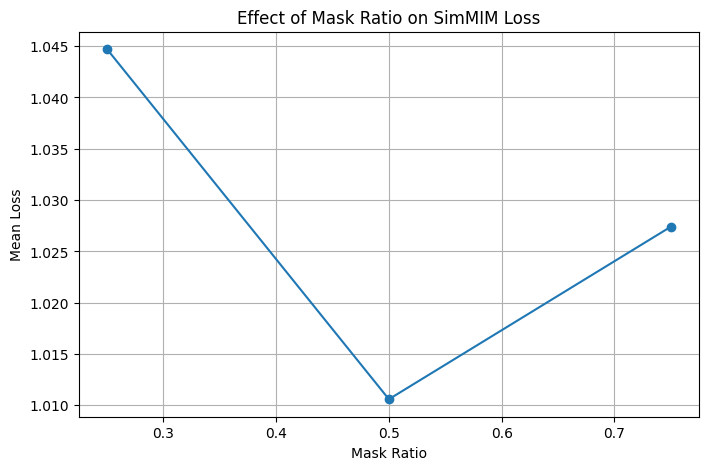

In [32]:
import matplotlib.pyplot as plt

x = [0.25, 0.50, 0.75]
y = [1.0447, 1.0106, 1.0274]

plt.figure(figsize=(8,5))
plt.plot(x, y, marker='o')
plt.xlabel("Mask Ratio")
plt.ylabel("Mean Loss")
plt.title("Effect of Mask Ratio on SimMIM Loss")
plt.grid(True)
plt.show()

## Figure Explanation

The figure visualizes how the mean loss changes when the mask ratio changes.

- X-axis: Mask Ratio
- Y-axis: Mean Training Loss

This helps us compare different masking levels more clearly than using raw numbers alone.

## Conclusion

Among the tested settings, mask ratio 0.50 achieved the lowest loss in our tiny-scale experiment.

This suggests that a moderate masking level may provide a better balance between task difficulty and learning signal.

However, since the dataset and training time were very small, these results should be treated as an initial pilot result rather than a final conclusion.